#A2 Simple Linear Regression Analysis

In [1]:
# IMPORTS

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# Display plots inline
%matplotlib inline

In [2]:
# LOAD DATA

# Load the CSV file
df = pd.read_csv('../data/data_full_story.csv')

# Check the shape of the data
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 620 rows, 8 columns


In [3]:
# EXPLORE DATA

# Preview first rows
df.head()

,name,story_score,agency_score,event_score,world_score,suspense_score,surprise_score,curiosity_score
0,t1_c95k50u,0.000000,1.0,1.0,1.000000,2.75,2.25,1.75
1,t1_c95mz3n,0.857143,4.0,5.0,1.000000,2.75,2.75,3.25
2,t1_c95l4my,0.857143,4.0,4.0,1.000000,2.75,3.25,3.50
3,t1_c95mcms,0.857143,5.0,5.0,1.000000,3.25,4.00,2.50
4,t3_1aenyc,1.000000,5.0,5.0,3.666667,2.75,3.50,3.75


In [4]:
# IDENTIFY RELEVANT COLUMNS

# List all columns
print("All columns:")
for col in df.columns:
    print(f"  - {col}")

All columns:
  - name
  - story_score
  - agency_score
  - event_score
  - world_score
  - suspense_score
  - surprise_score
  - curiosity_score


## Which variable is the dependent, which the independent variable?

- **Dependent variable (Y):** `story_score` (scale 0-1)
- **Independent variables (X):** (scale 1-5)
  - `agency_score` 
  - `event_score` 
  - `world_score` 
  - `suspense_score` 
  - `surprise_score` 
  - `curiosity_score`

In [5]:
# DEFINE VARIABLES

# Dependent variable
dependent_var = 'story_score'

# Independent variables (story features)
independent_vars = [
    'agency_score',
    'event_score', 
    'world_score',
    'suspense_score',
    'surprise_score',
    'curiosity_score'
]

print(f"Dependent variable: {dependent_var}")
print(f"Independent variables: {independent_vars}")

Dependent variable: story_score
Independent variables: ['agency_score', 'event_score', 'world_score', 'suspense_score', 'surprise_score', 'curiosity_score']


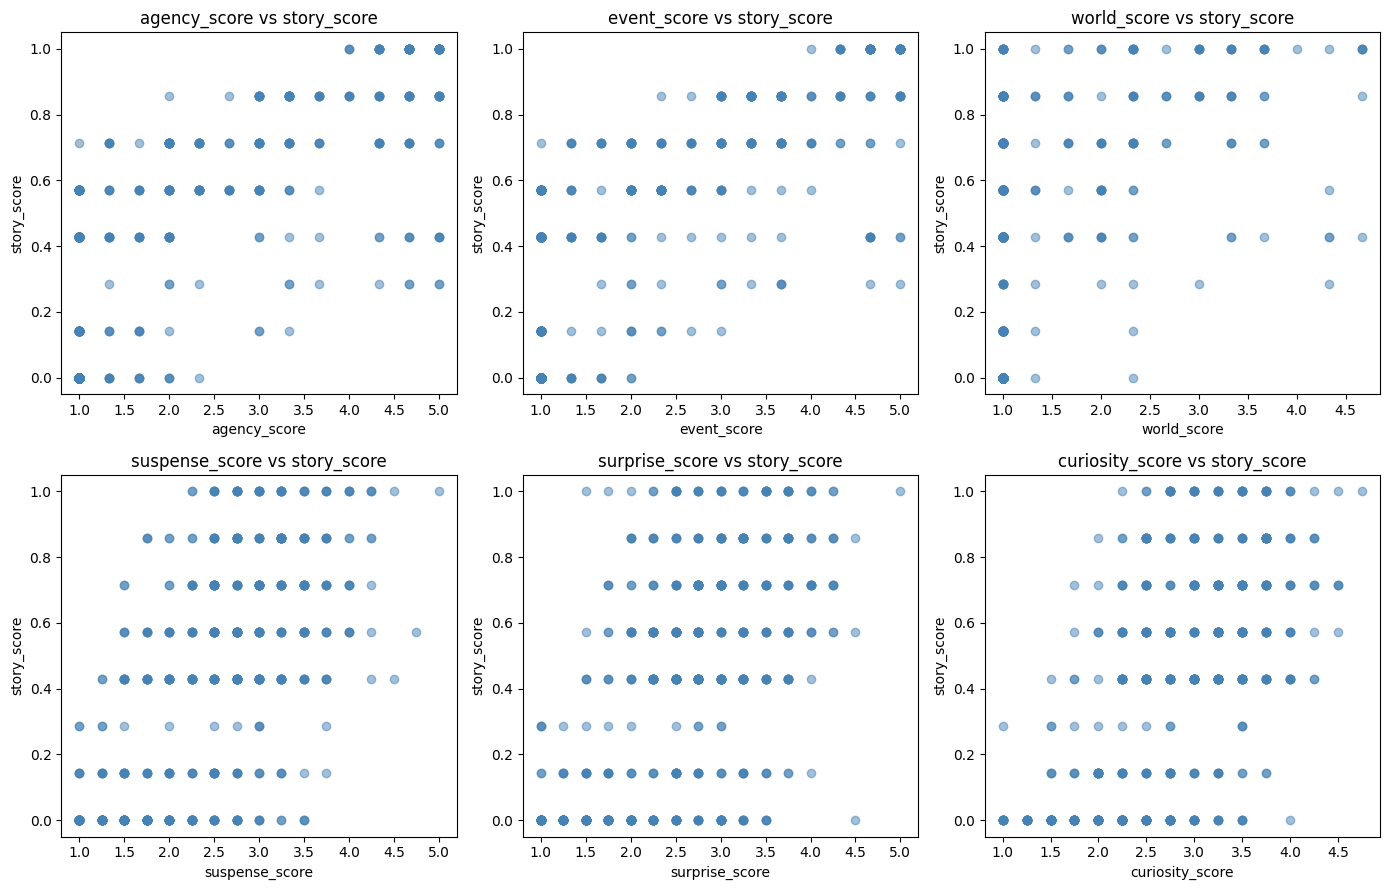

In [6]:
# SCATTERPLOTS: Story Features vs Story Score

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, var in enumerate(independent_vars):
    axes[idx].scatter(df[var], df[dependent_var], alpha=0.5, color='steelblue')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel(dependent_var)
    axes[idx].set_title(f'{var} vs {dependent_var}')

plt.tight_layout()
plt.show()

In [7]:
# SIMPLE LINEAR REGRESSION FOR EACH INDEPENDENT VARIABLE

# Store results
regression_results = {}

# Perform linear regression for each independent variable
for var in independent_vars:
    # Prepare data (X must be 2D array)
    X = df[[var]]
    y = df[dependent_var]
    
    # Create and fit the model
    model = LinearRegression()
    model.fit(X, y)
    
    # Store results
    regression_results[var] = {
        'model': model,
        'intercept': model.intercept_,
        'slope': model.coef_[0],
        'predictions': model.predict(X)
    }
    
    # Print results
    print(f"\n{var}:")
    print(f"  Intercept (b0): {model.intercept_:.4f}")
    print(f"  Slope (b1):     {model.coef_[0]:.4f}")
    print(f"  Equation: story_score = {model.intercept_:.4f} + {model.coef_[0]:.4f} * {var}")


agency_score:
  Intercept (b0): 0.0244
  Slope (b1):     0.1863
  Equation: story_score = 0.0244 + 0.1863 * agency_score

event_score:
  Intercept (b0): 0.0202
  Slope (b1):     0.1933
  Equation: story_score = 0.0202 + 0.1933 * event_score

world_score:
  Intercept (b0): 0.1454
  Slope (b1):     0.2020
  Equation: story_score = 0.1454 + 0.2020 * world_score

suspense_score:
  Intercept (b0): -0.2145
  Slope (b1):     0.2576
  Equation: story_score = -0.2145 + 0.2576 * suspense_score

surprise_score:
  Intercept (b0): -0.2014
  Slope (b1):     0.2386
  Equation: story_score = -0.2014 + 0.2386 * surprise_score

curiosity_score:
  Intercept (b0): -0.3195
  Slope (b1):     0.2655
  Equation: story_score = -0.3195 + 0.2655 * curiosity_score


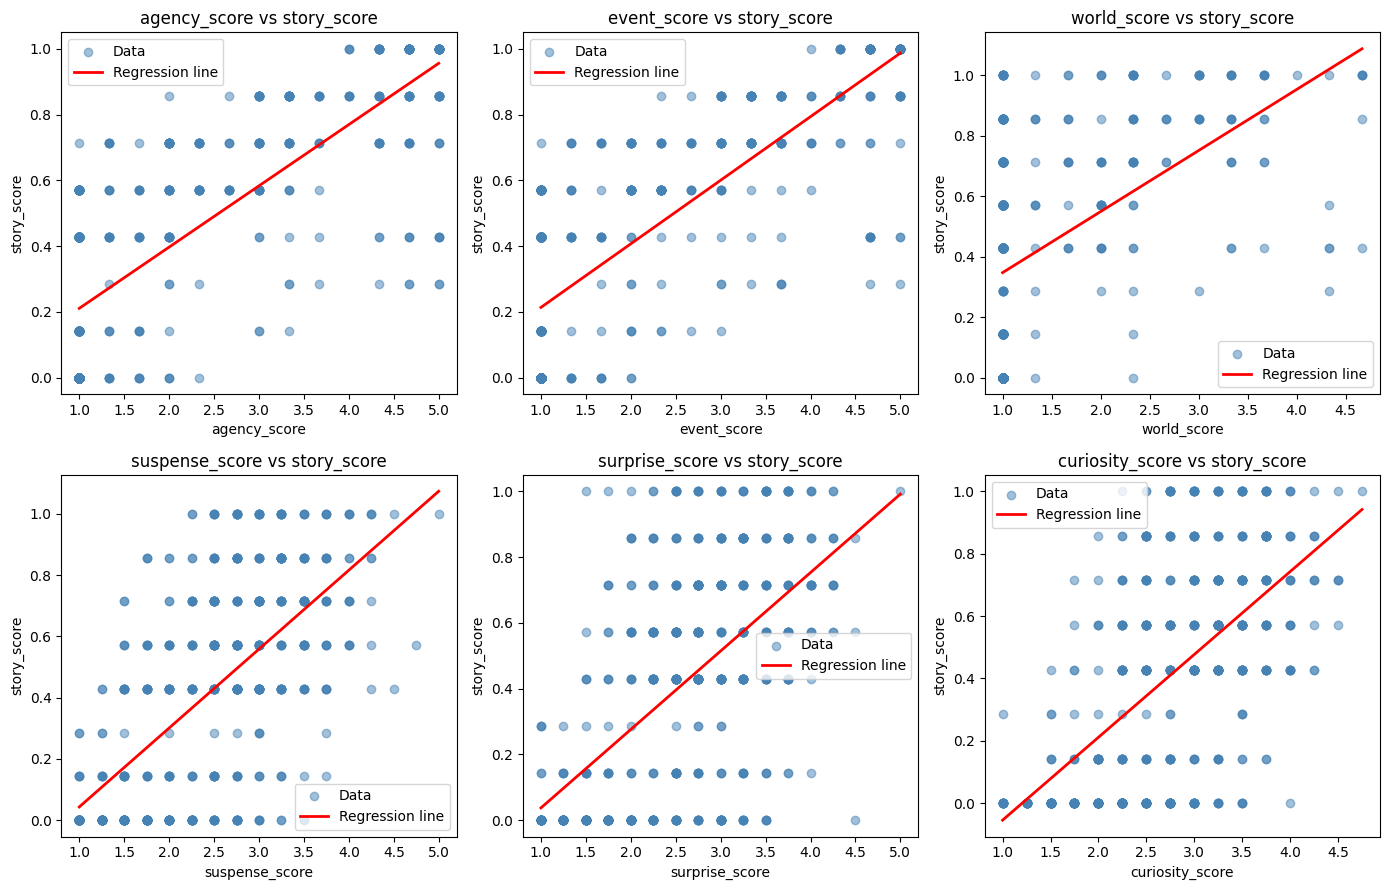

In [8]:
# SCATTERPLOTS WITH REGRESSION LINES

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, var in enumerate(independent_vars):
    # Get data
    X = df[var]
    y = df[dependent_var]
    predictions = regression_results[var]['predictions']
    
    # Scatter plot
    axes[idx].scatter(X, y, alpha=0.5, color='steelblue', label='Data')
    
    # Regression line
    axes[idx].plot(X.sort_values(), 
                   regression_results[var]['model'].predict(df[[var]].sort_values(by=var)),
                   color='red', linewidth=2, label='Regression line')
    
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel(dependent_var)
    axes[idx].set_title(f'{var} vs {dependent_var}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [12]:
# R² SCORE FOR EACH VARIABLE


print("R² Scores for each independent variable:")

r2_scores = {}

for var in independent_vars:
    y_true = df[dependent_var]
    y_pred = regression_results[var]['predictions']
    
    r2 = r2_score(y_true, y_pred)
    r2_scores[var] = r2
    
    print(f"{var:<20}: R² = {r2:.4f}")

# Find the best predictor
best_predictor = max(r2_scores, key=r2_scores.get)
print(f"\nBest predictor: {best_predictor} (R² = {r2_scores[best_predictor]:.4f})")

R² Scores for each independent variable:
agency_score        : R² = 0.5808
event_score         : R² = 0.5971
world_score         : R² = 0.2044
suspense_score      : R² = 0.4214
surprise_score      : R² = 0.3427
curiosity_score     : R² = 0.3614

Best predictor: event_score (R² = 0.5971)


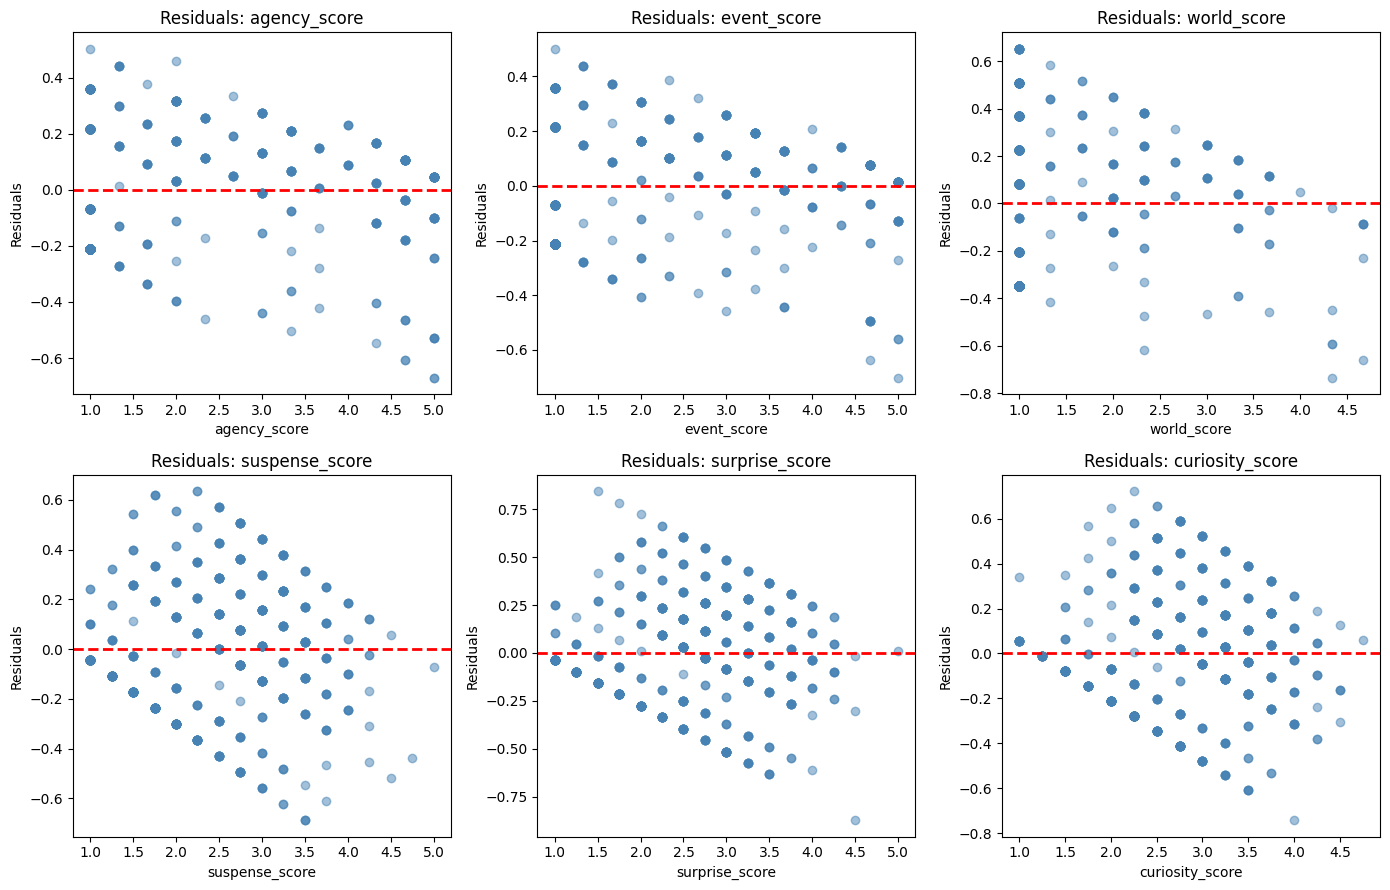

In [13]:
# RESIDUAL PLOTS

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

# Store residuals for later use (Shapiro-Wilk test)
all_residuals = {}

for idx, var in enumerate(independent_vars):
    y_true = df[dependent_var]
    y_pred = regression_results[var]['predictions']
    
    # Calculate residuals
    residuals = y_true - y_pred
    all_residuals[var] = residuals
    
    # Plot residuals
    axes[idx].scatter(df[var], residuals, alpha=0.5, color='steelblue')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'Residuals: {var}')

plt.tight_layout()
plt.show()

In [14]:
# SHAPIRO-WILK TEST FOR NORMALITY OF RESIDUALS

print("Shapiro-Wilk Test Results:")
print(f"{'Variable':<20} {'Statistic':<12} {'p-value':<12} {'Normal?'}")

for var in independent_vars:
    residuals = all_residuals[var]
    shapiro_test = stats.shapiro(residuals)
    
    # If p-value > 0.05, we cannot reject normality
    is_normal = "Yes" if shapiro_test.pvalue > 0.05 else "No"
    
    print(f"{var:<20} {shapiro_test.statistic:<12.4f} {shapiro_test.pvalue:<12.4f} {is_normal}")


print("\nInterpretation: p-value > 0.05 suggests residuals are normally distributed")

Shapiro-Wilk Test Results:
Variable             Statistic    p-value      Normal?
agency_score         0.9434       0.0000       No
event_score          0.9427       0.0000       No
world_score          0.9143       0.0000       No
suspense_score       0.9942       0.0179       No
surprise_score       0.9955       0.0719       Yes
curiosity_score      0.9887       0.0001       No

Interpretation: p-value > 0.05 suggests residuals are normally distributed


In [15]:
# SUMMARY TABLE: ALL RESULTS

summary_data = []

for var in independent_vars:
    shapiro_test = stats.shapiro(all_residuals[var])
    
    summary_data.append({
        'Variable': var,
        'Slope': regression_results[var]['slope'],
        'Intercept': regression_results[var]['intercept'],
        'R²': r2_scores[var],
        'Shapiro p-value': shapiro_test.pvalue,
        'Normal Residuals': 'Yes' if shapiro_test.pvalue > 0.05 else 'No'
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values(by='R²', ascending=False).reset_index(drop=True)

print("Summary of Linear Regression Results:")
print(summary_df.to_string(index=False))

Summary of Linear Regression Results:
       Variable    Slope  Intercept       R²  Shapiro p-value Normal Residuals
    event_score 0.193348   0.020187 0.597139     9.875590e-15               No
   agency_score 0.186280   0.024370 0.580823     1.239786e-14               No
 suspense_score 0.257571  -0.214501 0.421431     1.790913e-02               No
curiosity_score 0.265492  -0.319473 0.361423     1.053884e-04               No
 surprise_score 0.238566  -0.201408 0.342729     7.191333e-02              Yes
    world_score 0.201972   0.145410 0.204418     3.122521e-18               No
